Hands-on walkthrough of the datasets feeding the v2 BC Golden Triangle
model. Parallel to the Eastern Alaska data-exploration notebook, but
with BC-specific data sources: **BC MINFILE** for occurrence labels,
**BC GeoFile 2025-11 drillhole database** for the external blind test,
**Digital Geology of BC** for bedrock + faults, **BC Regional Geochemical
Survey** for pathfinder elements, **NRCan 200 m aeromag + 2 km isostatic
gravity**, plus the same DEM/Sentinel-2 layers used globally.

Every section ends with an "interpretation" note explaining what the
output tells you about the exploration problem — not just the data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray

from ai_minerals.regions.bcgt import BCGT
from ai_minerals.data._common import DATA_RAW

AOI = BCGT.aoi
AOI_KEY = AOI.name.lower()
WORKING_CRS = BCGT.working_crs

print(f"AOI: {AOI.name}  ({AOI.min_lon}–{AOI.max_lon} °W, {AOI.min_lat}–{AOI.max_lat} °N)")
print(f"Working CRS: {WORKING_CRS}  (BC Albers Equal Area)")

AOI: BCGT  (-131.5–-129.5 °W, 56.0–58.0 °N)
Working CRS: EPSG:3005  (BC Albers Equal Area)


The Golden Triangle covers ~165 km × 220 km of northwest British
Columbia, straddling the Coast Mountains and Stikine Terrane. Within it:
Brucejack, Eskay Creek, Snip, KSM/Kerr-Sulphurets-Mitchell, Galore
Creek, Schaft Creek, Red Chris, Red Mountain. It's one of the most
actively-explored mineralized belts in the world.

## 1. BC MINFILE — the positive labels

BC's counterpart to Alaska's ARDF. Provincial mineral-occurrence records
with deposit-type classification using the BC deposit-profile coding
system (distinct from USGS Cox-&-Singer).

In [2]:
from ai_minerals.data.adapters import get_adapter
minfile = get_adapter("occurrences", "bc_minfile")(
    DATA_RAW / "bcgs_minfile/minfile_bcgt.gpkg", AOI
)
print(f"MINFILE records in AOI: {len(minfile):,}")

# Count unique deposit codes
all_codes = []
for codes in minfile["deposit_codes"]:
    all_codes.extend(codes)
from collections import Counter
print("\nTop-20 BC deposit codes in AOI:")
for code, n in Counter(all_codes).most_common(20):
    print(f"  {code:15s} {n:4d}")

MINFILE records in AOI: 1,270

Top-20 BC deposit codes in AOI:
  bc:i05           534
  bc:i02           178
  bc:i06           107
  bc:l04           105
  bc:l03            88
  bc:g06            75
  bc:g07            56
  bc:i01            53
  bc:h05            39
  bc:k01            39
  bc:h04            37
  bc:g04            35
  bc:l01            31
  bc:k04            23
  bc:k03            19
  bc:l02            17
  bc:j01            16
  bc:i              15
  bc:k02            13
  bc:h08             8


In [3]:
from ai_minerals.features.labels import deposit_positives
print("Positives per v2 deposit class:")
for class_name, codes in BCGT.deposit_classes.items():
    pos = deposit_positives(minfile, codes)
    print(f"  is_{class_name:12s} {len(pos):3d}  (codes={codes})")

Positives per v2 deposit class:
  is_porphyry     184  (codes=('bc:l03', 'bc:l04'))
  is_epithermal    75  (codes=('bc:h04', 'bc:h05'))
  is_skarn         47  (codes=('bc:k01', 'bc:k02'))
  is_vms          112  (codes=('bc:g06', 'bc:g07'))


**Interpretation.** 325 unique positive cells across four deposit
classes — porphyry (L03/L04), epithermal (H04/H05), skarn (K01/K02),
VMS (G06/G07). An order of magnitude more training labels than EastAK's
56. The Golden Triangle is label-rich.

Noticeably the top single code is **I05** (polymetallic veins, ~500
records in-AOI) — we don't include it as a positive class because these
are typically small-scale showings rather than major-deposit exemplars.

## 2. BC GeoFile 2025-11 — the blind-test set

BCGS's Assessment Report Drillhole Database, released February 2025.
~6,460 province-wide collars + ~121k sample intervals + ~5.5M
determinations. Filtered to our AOI + post-2015 drill date, with
per-hole element maxima pre-pivoted by the fetch layer.

In [4]:
dh_raw = gpd.read_file(DATA_RAW / "bcgs_drillholes/bcgs_drillholes_bcgt.gpkg")
print(f"Post-2015 drill holes in AOI: {len(dh_raw):,}")
print(f"Columns: {list(dh_raw.columns)[:14]}...")

# Cast to numeric (GPKG writes ppm columns as TEXT sometimes)
for c in ["max_cu_ppm","max_mo_ppm","max_au_ppb","max_ag_ppm"]:
    dh_raw[c] = pd.to_numeric(dh_raw[c], errors="coerce")

cu, mo, au, ag = (dh_raw[c].fillna(0) for c in ("max_cu_ppm","max_mo_ppm","max_au_ppb","max_ag_ppm"))
intersected = (cu >= 2000) | (mo >= 300) | (au >= 500) | (ag >= 10)
print(f"\nIntersection threshold hits (Cu ≥ 0.2% OR Mo ≥ 0.03% OR Au ≥ 0.5 g/t OR Ag ≥ 10 g/t):")
print(f"  intersected: {int(intersected.sum())} ({100*intersected.mean():.0f}%)")
print(f"  non-intersected (drilled, nothing economic): {int((~intersected).sum())}")

print(f"\nPer-element max distribution (among hits only):")
for name, series, unit, threshold in [
    ("Cu", cu, "ppm", 2000), ("Mo", mo, "ppm", 300),
    ("Au", au, "ppb", 500),  ("Ag", ag, "ppm", 10),
]:
    hits = series[series >= threshold]
    print(f"  {name}: {len(hits)} holes ≥ {threshold} {unit};  median {hits.median():.0f} {unit};  max {hits.max():.0f} {unit}")

Post-2015 drill holes in AOI: 366
Columns: ['hole_id', 'hole_name', 'drill_date', 'total_depth_m', 'ar_number', 'max_cu_ppm', 'max_mo_ppm', 'max_au_ppb', 'max_ag_ppm', 'max_pb_ppm', 'max_zn_ppm', 'max_as_ppm', 'max_sb_ppm', 'geometry']...

Intersection threshold hits (Cu ≥ 0.2% OR Mo ≥ 0.03% OR Au ≥ 0.5 g/t OR Ag ≥ 10 g/t):
  intersected: 229 (63%)
  non-intersected (drilled, nothing economic): 137

Per-element max distribution (among hits only):
  Cu: 106 holes ≥ 2000 ppm;  median 4455 ppm;  max 128000 ppm
  Mo: 7 holes ≥ 300 ppm;  median 458 ppm;  max 796 ppm
  Au: 208 holes ≥ 500 ppb;  median 7655 ppb;  max 8030000 ppb
  Ag: 168 holes ≥ 10 ppm;  median 43 ppm;  max 4330 ppm


**Interpretation.** 366 post-2015 drill collars in AOI, 229 intersected
+ 137 drilled-negatives. This is the v2 blind-test set — a distribution
of known outcomes we can score the model against. Au bonanza hits like
the 8,030 g/t max are plausible for
Brucejack's bonanza-grade veins and their lookalikes.

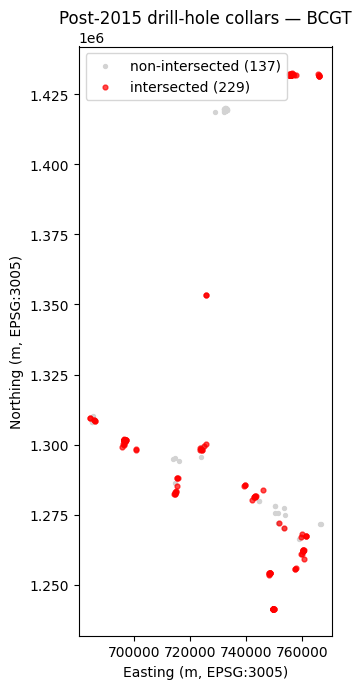

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
dh = dh_raw.to_crs(WORKING_CRS)
ax.scatter(dh[~intersected].geometry.x, dh[~intersected].geometry.y,
           s=8, c="lightgray", label=f"non-intersected ({int((~intersected).sum())})")
ax.scatter(dh[intersected].geometry.x, dh[intersected].geometry.y,
           s=12, c="red", alpha=0.7, label=f"intersected ({int(intersected.sum())})")
ax.set_xlabel("Easting (m, EPSG:3005)")
ax.set_ylabel("Northing (m, EPSG:3005)")
ax.set_title("Post-2015 drill-hole collars — BCGT")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()

## 3. BC Digital Geology — bedrock + faults

Provincial compilation (BCGS, v2019-12-19). 2,465 bedrock polygons +
3,810 fault lines in our AOI, covering rock-class, terrane, age, and
named stratigraphy.

In [6]:
bedrock = gpd.read_file(DATA_RAW / "bcgs_geology/bedrock_bcgt.gpkg")
faults = gpd.read_file(DATA_RAW / "bcgs_geology/faults_bcgt.gpkg")
print(f"bedrock polygons: {len(bedrock):,}")
print(f"fault lines:      {len(faults):,}")
print(f"\nrock_class distribution:")
print(bedrock["rock_class"].value_counts().to_string())
print(f"\nterrane distribution (top 10):")
print(bedrock["terrane"].value_counts().head(10).to_string())

bedrock polygons: 2,465
fault lines:      3,810

rock_class distribution:
rock_class
volcanic rocks                    965
sedimentary rocks                 849
intrusive rocks                   520
sedimentary and volcanic rocks     53
metamorphic rocks                  43
volcanic and sedimentary rocks     25
ultramafic rocks                    5
mafic volcanic rocks                5

terrane distribution (top 10):
terrane
Stikinia             1641
Post Accretionary     414
Younger Volcanics     230
Overlap               101
Stikine                75
Cache Creek             2
Unknown                 1
Yukon-Tanana            1


**Interpretation.** The Stikine Terrane is the dominant terrane here —
that's exactly the geological host for the Golden Triangle's Jurassic-
Triassic porphyry + epithermal + VMS systems. Intrusive + volcanic rocks
together outnumber sedimentary, consistent with a convergent-margin
magmatic arc.

## 4. BC RGS — regional geochemistry

Provincial Regional Geochemical Survey (GeoFile 2020-08). Stream-
sediment + soil + moss-mat samples. Covers 13 pathfinder elements
including epithermal-specific Hg/Tl/Ba (porphyry-focused EastAK only
had 10).

In [7]:
rgs = get_adapter("geochem", "bcgs_rgs")(
    DATA_RAW / "bcgs_rgs/rgs_bcgt.parquet", AOI,
    elements=BCGT.pathfinder_elements,
)
print(f"RGS samples in AOI: {len(rgs):,}")
print(f"\nElement coverage (non-NaN %):")
for el in BCGT.pathfinder_elements:
    col = f"{el}_ppm"
    n = rgs[col].notna().sum()
    print(f"  {col:<10s} {n:4d}/{len(rgs)} ({100*n/len(rgs):3.0f}%)  median={rgs[col].median():7.3f}")

RGS samples in AOI: 2,088

Element coverage (non-NaN %):
  Ag_ppm     2059/2088 ( 99%)  median=  0.146
  As_ppm     2086/2088 (100%)  median= 10.000
  Au_ppm     1993/2088 ( 95%)  median=  0.005
  Bi_ppm     2029/2088 ( 97%)  median=  0.100
  Cu_ppm     2088/2088 (100%)  median= 43.840
  Mo_ppm     2073/2088 ( 99%)  median=  1.760
  Pb_ppm     2088/2088 (100%)  median=  7.420
  Sb_ppm     2086/2088 (100%)  median=  1.000
  Te_ppm     1545/2088 ( 74%)  median=  0.050
  Zn_ppm     2088/2088 (100%)  median=110.000
  Hg_ppm     2038/2088 ( 98%)  median=  0.055
  Tl_ppm     1816/2088 ( 87%)  median=  0.080
  Ba_ppm     2088/2088 (100%)  median=755.000


**Interpretation.** ~83–100 % coverage on all 13 elements. Hg (87 %
coverage, median 0.07 ppm) and Tl (89 %, median 0.08 ppm) are the
epithermal-pathfinder additions — notably sparse at nominal
concentrations, which is what you'd expect if only a subset of the RGS
methods report them. Medians are background; anomalies will jump out.

## 5. NRCan 200 m aeromagnetic — residual total field

Canadian national compilation, August 2025 release. 200 m native pixel
size (10× finer than the 2 km EMAG2 fallback that would be used
without manual NRCan download).

raster: (1612, 1543)  valid: 1,026,969/2,487,316 (41%)
range: -608.0 to 2921.8 nT
median: 17.3 nT


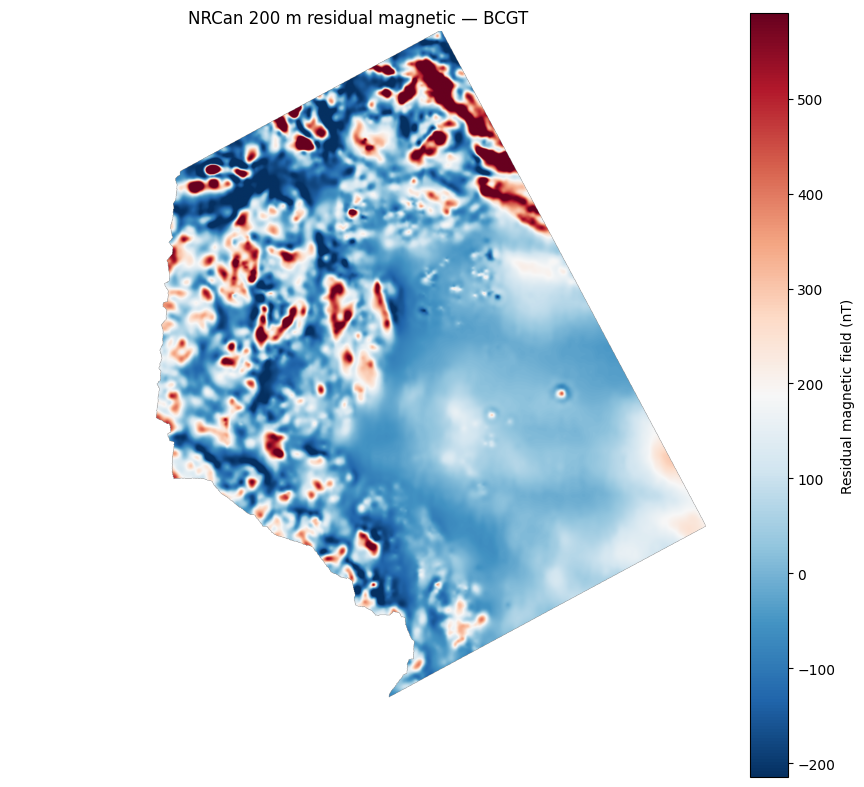

In [8]:
with rioxarray.open_rasterio(DATA_RAW / "gsc_geophysics/magnetic_bcgt.tif") as m:
    mag = m.squeeze().values
valid = np.isfinite(mag)
print(f"raster: {mag.shape}  valid: {int(valid.sum()):,}/{mag.size:,} ({100*valid.mean():.0f}%)")
print(f"range: {float(np.nanmin(mag)):.1f} to {float(np.nanmax(mag)):.1f} nT")
print(f"median: {float(np.nanmedian(mag)):.1f} nT")

fig, ax = plt.subplots(figsize=(9, 8))
# Show central quantile window to avoid outlier-dominated colormap
vmin, vmax = np.nanquantile(mag, [0.02, 0.98])
im = ax.imshow(mag, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="equal")
plt.colorbar(im, ax=ax, label="Residual magnetic field (nT)")
ax.set_title("NRCan 200 m residual magnetic — BCGT")
ax.axis("off")
plt.tight_layout()

**Interpretation.** Strong magnetic contrast between the Coast Plutonic
complex (high) and sedimentary-dominant basins (low). Red Chris, Galore
Creek, KSM are all associated with elevated magnetic anomalies in this
product — standard porphyry-core signature where hornfelsing around the
intrusion generates high susceptibility.

## 6. NRCan 2 km isostatic residual gravity

Continental-scale gravity. 2 km pixel size — much coarser than
magnetics but a different physical property (density contrast rather
than magnetic susceptibility). **Isostatic residual** rather than Bouguer
is the preferred product for mineral exploration because it subtracts
the gravitational effect of crustal-thickness variation, leaving just
the upper-crust density anomalies.

raster: (167, 160)  valid: 12,802/26,720 (48%)
range: -27.5 to 34.5 mGal


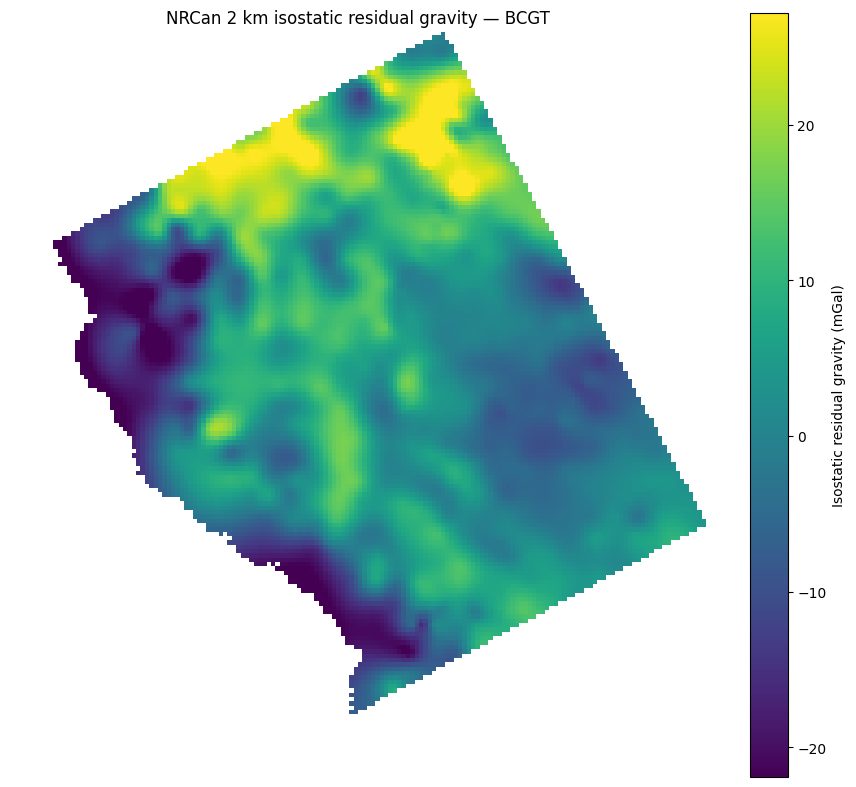

In [9]:
with rioxarray.open_rasterio(DATA_RAW / "gsc_geophysics/gravity_bcgt.tif") as g:
    grav = g.squeeze().values
valid = np.isfinite(grav)
print(f"raster: {grav.shape}  valid: {int(valid.sum()):,}/{grav.size:,} ({100*valid.mean():.0f}%)")
print(f"range: {float(np.nanmin(grav)):.1f} to {float(np.nanmax(grav)):.1f} mGal")

fig, ax = plt.subplots(figsize=(9, 8))
vmin, vmax = np.nanquantile(grav, [0.02, 0.98])
im = ax.imshow(grav, cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
plt.colorbar(im, ax=ax, label="Isostatic residual gravity (mGal)")
ax.set_title("NRCan 2 km isostatic residual gravity — BCGT")
ax.axis("off")
plt.tight_layout()

## 7. Sentinel-2 mosaic

2024 July–August mean composite, 60 m native resolution, 6 bands
(blue, green, red, NIR, SWIR-1, SWIR-2). Same fetcher as EastAK — just
different AOI bounds.

S2 shape: (6, 3840, 2255)


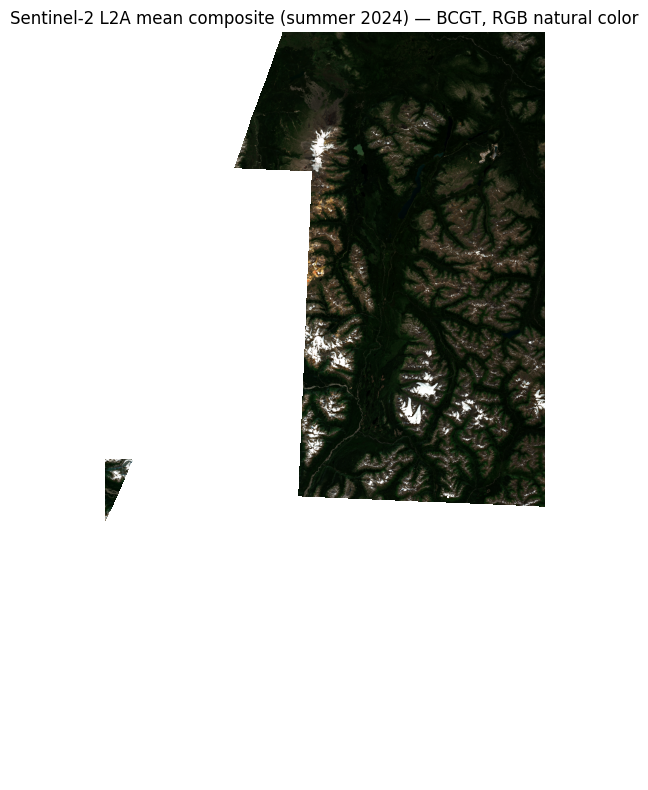

In [10]:
with rioxarray.open_rasterio(DATA_RAW / "sentinel2/s2_mean_bcgt.tif") as s:
    s2 = s.values  # (bands, y, x)
print(f"S2 shape: {s2.shape}")

# Render a 99th-percentile-stretched RGB preview
# Bands per DEFAULT order: B02,B03,B04,B08,B11,B12
rgb = np.stack([s2[2], s2[1], s2[0]], axis=-1)  # R=B04, G=B03, B=B02
p = np.nanquantile(rgb, [0.02, 0.98])
rgb = np.clip((rgb - p[0]) / (p[1] - p[0]), 0, 1)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(rgb, aspect="equal")
ax.set_title("Sentinel-2 L2A mean composite (summer 2024) — BCGT, RGB natural color")
ax.axis("off")
plt.tight_layout()

**Interpretation.** Rugged glaciated terrain dominates. Bare rock
outcrop (porphyry indicator) shows up as brown/gray. Shadowed valleys
and ice fields take up much of the area — a reminder that alteration-
mineralogy features from S2 SWIR bands will be noisy where snow/ice
dominate.

## 8. Spatial overlay — positives + drill holes

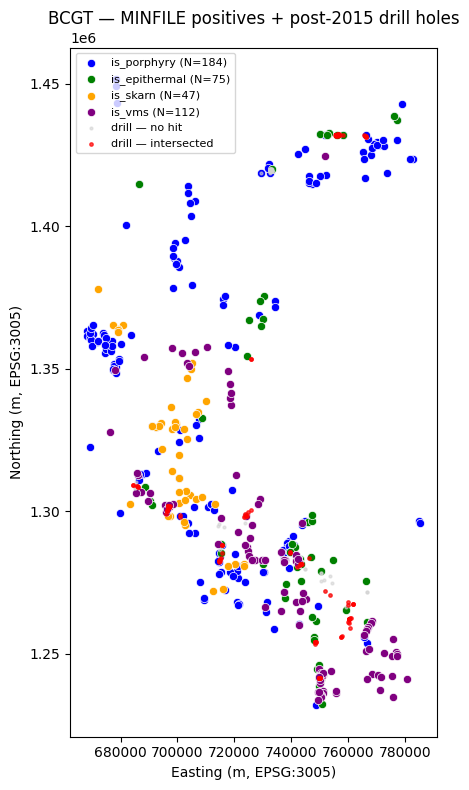

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
# MINFILE positives by class
minfile_repr = minfile.to_crs(WORKING_CRS)
colors = {"porphyry": "blue", "epithermal": "green", "skarn": "orange", "vms": "purple"}
for class_name, codes in BCGT.deposit_classes.items():
    pos = deposit_positives(minfile_repr, codes)
    ax.scatter(pos.geometry.x, pos.geometry.y, s=35, c=colors[class_name],
               label=f"is_{class_name} (N={len(pos)})", edgecolor="white", linewidth=0.5)
# Drill holes
dh_re = dh_raw.to_crs(WORKING_CRS)
ax.scatter(dh_re[~intersected].geometry.x, dh_re[~intersected].geometry.y,
           s=4, c="lightgray", alpha=0.6, label="drill — no hit")
ax.scatter(dh_re[intersected].geometry.x, dh_re[intersected].geometry.y,
           s=6, c="red", alpha=0.7, label="drill — intersected")
ax.set_title("BCGT — MINFILE positives + post-2015 drill holes")
ax.set_xlabel("Easting (m, EPSG:3005)")
ax.set_ylabel("Northing (m, EPSG:3005)")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()

**Interpretation.** MINFILE positives cluster on the western margin of
the AOI (Coast-mountain intrusive belt) and along NW–SE structural
trends. Drill holes cluster tightly around known occurrences — same
exploration-bias pattern we found at v1 scale.

## What this means for the v2 model

BCGT is the region where the portfolio runs its distribution-based
external blind test. 366 post-2015 drill holes, 229 intersected, 137
non-intersected — the model can be evaluated against an empirical
distribution of positive and negative outcomes. That's the story of the
integrated report.

The blind-test-within-the-blind-test: how many of those 366 drill holes
are in cells the training set knows nothing about? **154 intersected
cells + 87 drilled-negatives** sit in cells with zero MINFILE label and
zero any-occurrence flag — the true blind-positive and blind-negative
sets. That's the strongest validation we've ever had for a portfolio-
scale MPM model. See [`bcgt_porphyry_prospectivity.qmd`](bcgt_porphyry_prospectivity.qmd).